<a href="https://colab.research.google.com/github/nurfnick/Numerical_Methods/blob/master/Module_5_Interpolation/linearSplinesAnimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D Cartoon Character Animation Using Linear Splines

In this notebook, we construct a 3D cartoon character defined by a set of joint vertices and skeletal connections. To animate the character, we specify two keyframes (Start and End poses) and apply **linear spline interpolation (Lerp)** to compute the intermediate positions across 5 frames.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Define the structural connections of our cartoon character (bones connecting joints)
# Joints: 0: Base/Pelvis, 1: Chest, 2: Head, 3: Left Shoulder, 4: Left Hand,
#         5: Right Shoulder, 6: Right Hand, 7: Left Hip, 8: Left Foot, 9: Right Hip, 10: Right Foot

connections = [
    (0, 1), # Spine
    (1, 2), # Neck/Head
    (1, 3), (3, 4), # Left Arm
    (1, 5), (5, 6), # Right Arm
    (0, 7), (7, 8), # Left Leg
    (0, 9), (9, 10) # Right Leg
]

# 2. Define the keyframes (Start and End configurations in 3D space)
# Each configuration is an array of shape (11, 3) representing (x, y, z) for each joint.

pose_start = np.array([
    [0.0, 0.0, 0.0],   # 0: Pelvis
    [0.0, 0.0, 1.0],   # 1: Chest
    [0.0, 0.0, 1.5],   # 2: Head
    [-0.5, 0.0, 1.0],  # 3: Left Shoulder
    [-1.0, 0.0, 0.5],  # 4: Left Hand (lowered)
    [0.5, 0.0, 1.0],   # 5: Right Shoulder
    [1.0, 0.0, 0.5],   # 6: Right Hand (lowered)
    [-0.3, 0.0, -0.5], # 7: Left Hip
    [-0.3, 0.0, -1.5], # 8: Left Foot
    [0.3, 0.0, -0.5],  # 9: Right Hip
    [0.3, 0.0, -1.5]   # 10: Right Foot
])

pose_end = np.array([
    [0.0, 0.2, 0.0],   # 0: Pelvis (slightly shifted forward)
    [0.0, 0.1, 1.0],   # 1: Chest
    [0.1, 0.0, 1.6],   # 2: Head (tilted up/back)
    [-0.5, 0.2, 1.0],  # 3: Left Shoulder
    [-1.2, 0.5, 1.8],  # 4: Left Hand (raised high waving)
    [0.5, 0.2, 1.0],   # 5: Right Shoulder
    [1.2, -0.5, 1.5],  # 6: Right Hand (extended outward)
    [-0.3, 0.4, -0.4], # 7: Left Hip
    [-0.5, 0.8, -1.2], # 8: Left Foot (taking a step)
    [0.3, -0.2, -0.6], # 9: Right Hip
    [0.3, -0.4, -1.6]  # 10: Right Foot
])

### Linear Spline Interpolation (Lerp)
To transition linearly from the start pose to the end pose over $N$ frames, we compute the position at step $t \in [0, 1]$ using:
$$P(t) = (1 - t) \cdot P_{\text{start}} + t \cdot P_{\text{end}}$$

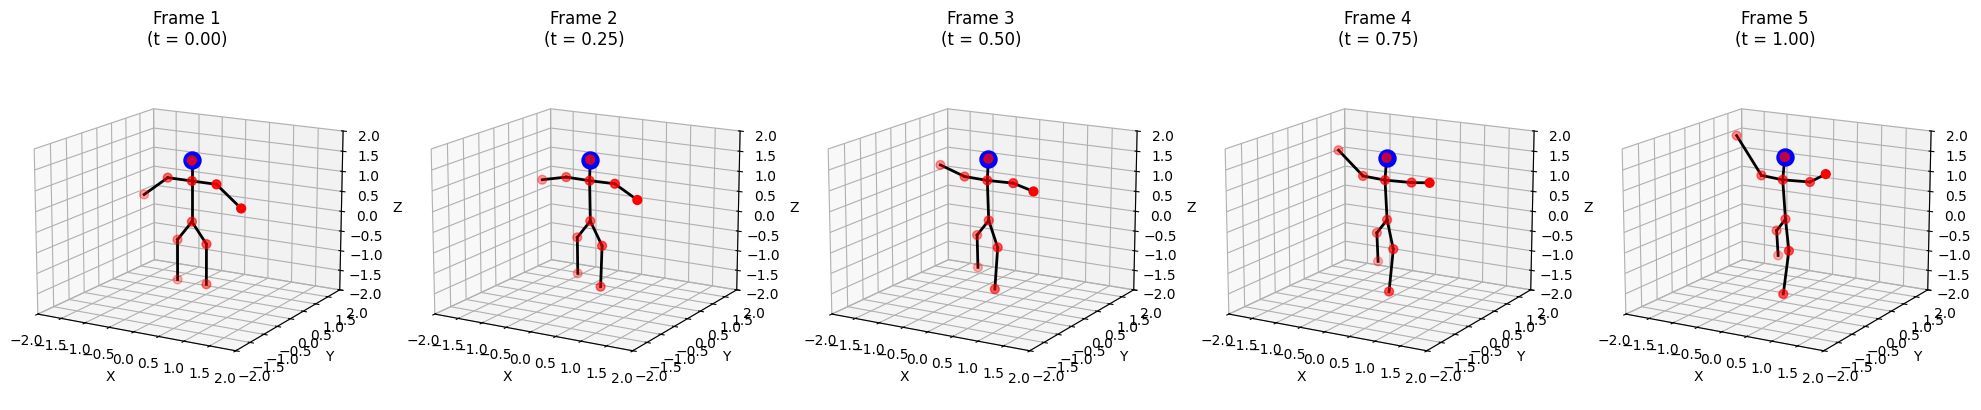

In [2]:
num_frames = 5
t_values = np.linspace(0, 1, num_frames)

# Create a 3D visualization grid for the 5 frames
fig = plt.figure(figsize=(20, 4))

for i, t in enumerate(t_values):
    # Apply the linear spline formula to all vertices simultaneously
    current_pose = (1 - t) * pose_start + t * pose_end

    ax = fig.add_subplot(1, num_frames, i + 1, projection='3d')

    # Plot joints
    ax.scatter(current_pose[:, 0], current_pose[:, 1], current_pose[:, 2], color='red', s=40, zorder=5)
    # Explicitly highlight the head
    ax.scatter(current_pose[2, 0], current_pose[2, 1], current_pose[2, 2], color='blue', s=150, label='Head' if i==0 else "")

    # Plot bones (linear connections)
    for connection in connections:
        joint_a = current_pose[connection[0]]
        joint_b = current_pose[connection[1]]
        ax.plot([joint_a[0], joint_b[0]],
                [joint_a[1], joint_b[1]],
                [joint_a[2], joint_b[2]], color='black', linewidth=2)

    ax.set_title(f"Frame {i+1}\n(t = {t:.2f})")
    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    ax.set_zlim([-2, 2])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=15, azim=-60)

plt.tight_layout()
plt.show()